# Understanding Measure Theory and the Lebesgue Integral

## Setup

In [2]:
from manim import *
import numpy as np
import random
config.media_width = "75%"
config.verbosity = "WARNING"

heading_gradient_colors = ["#03fcca", "#f21de8"]
#gradient_colors = ["#D4145A", "#FBB03B"]
#gradient_colors = ["#009245", "#FCEE21"]
gradient_colors = ["#FF512F", "#DD2476"]

#primary = "#DE286F"
primary = "#58C4DD"

secondary = "#FC6255"

tertiary = "#83C167"

grid_color = "#5CD0B3"

highlight_color = "#029782"

Manim Community v0.18.1

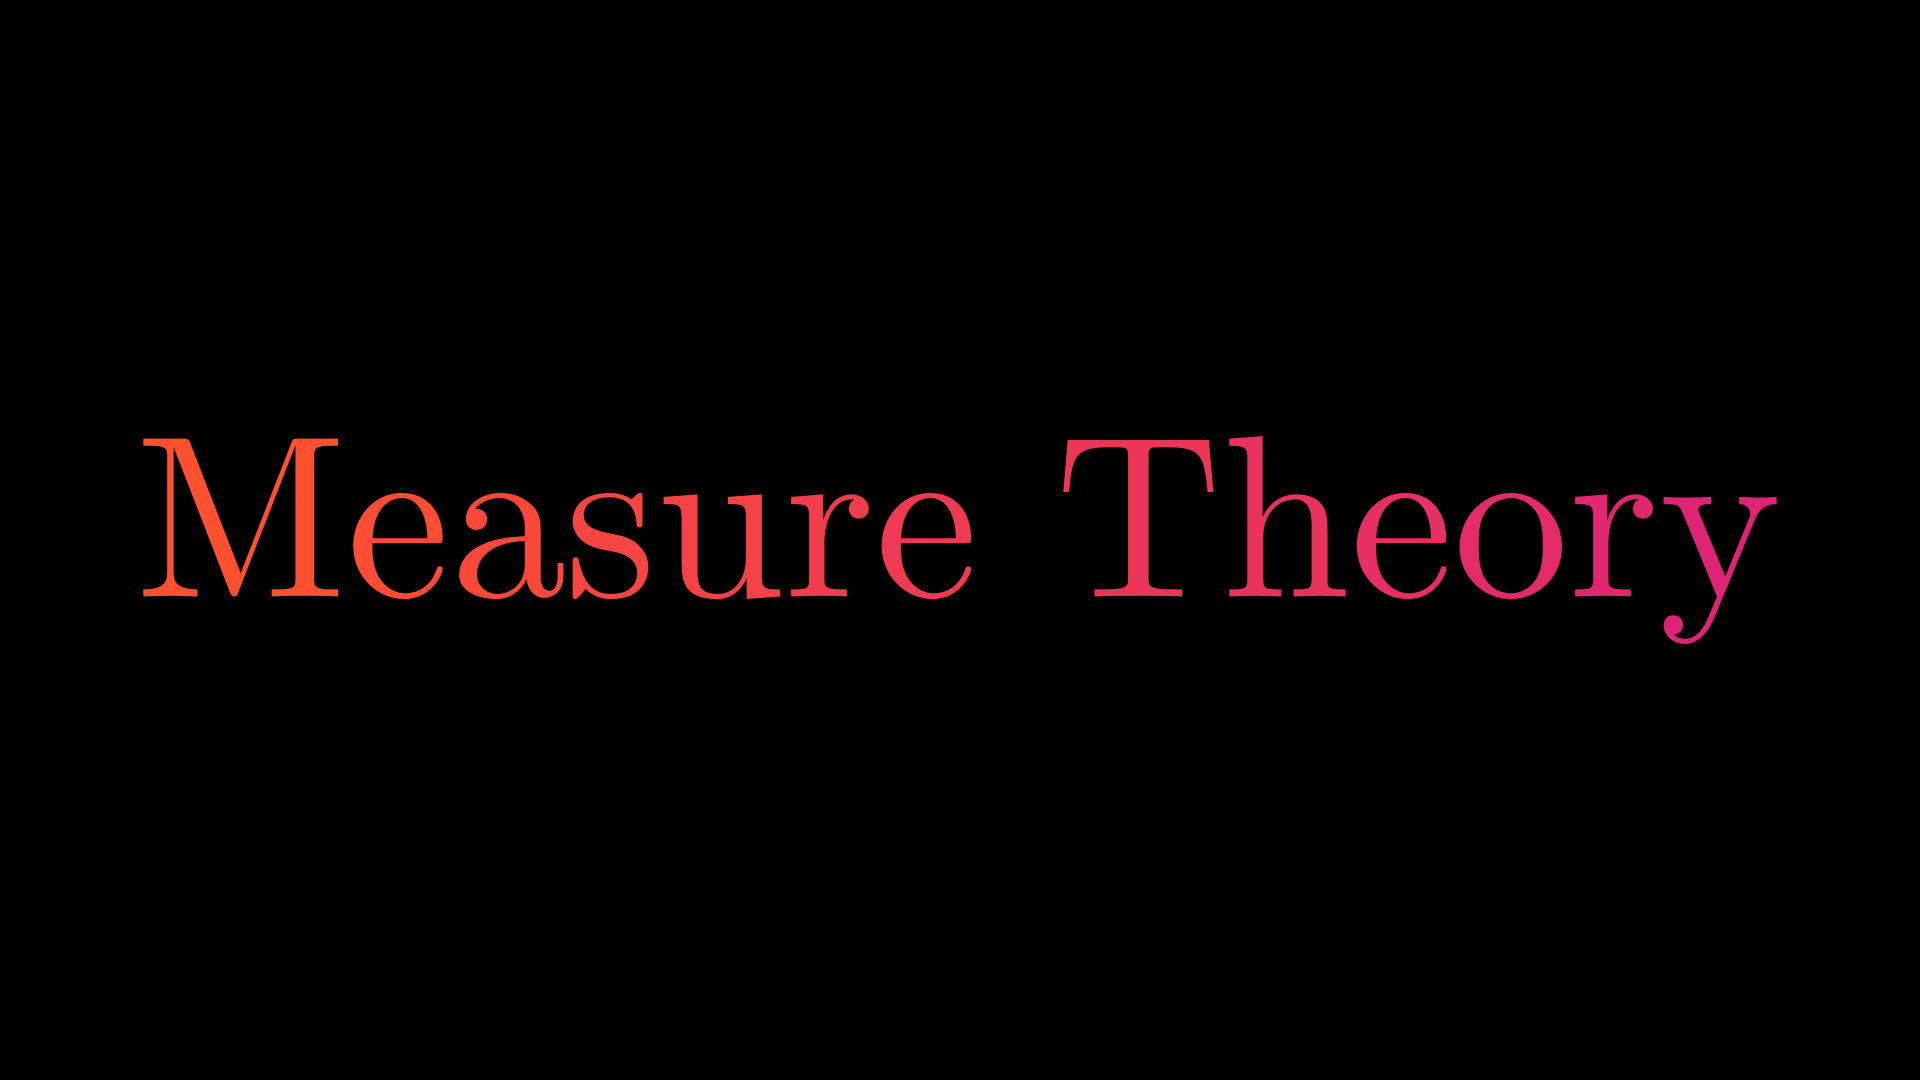

In [11]:
%%manim -qh Thumbnail

class Thumbnail(Scene):
    def construct(self):
        title = Tex("Measure Theory", font_size=165)
        title.set_color_by_gradient(*gradient_colors)
        self.add(title)
        

## 1. Introduction

In [3]:
%%manim -qm C1S1

class C1S1(Scene):
    def construct(self):
        # Create the chapter title text
        chapter_title = Tex(r"\MakeUppercase{\romannumeral 1} \textbf{Introduction}", font_size=100)
        chapter_title.set_color_by_gradient(*heading_gradient_colors)
        
        # Add a fade-out transition
        self.play(
            Write(chapter_title)
        )
        self.wait()
        self.play(
            FadeOut(chapter_title)
        )

Manim Community v0.18.1

### Riemann integral of a continuous function

In [4]:
%%manim -qm C1S2

# Riemann Rectangles
class C1S2(Scene):
    def construct(self):
        f1 = lambda x: 0.1*(x+2)*(x-3)*(x-6)
        x_range = [-2,3]

        axes = Axes(
            x_range=[-8, 8.3, 1],
            y_range=[-3, 5, 1],
            x_length=10,
            axis_config={"color": WHITE},
            x_axis_config={
                "numbers_to_include": np.arange(-8, 8.01, 2),
                "numbers_with_elongated_ticks": np.arange(-8, 8.01, 2),
            },
            y_axis_config={
                "numbers_to_include": np.arange(-2, 4.01, 1),
            },
            tips=False,
        )
        f1_graph = axes.plot(f1, color=primary)
        f1_graph.z_index=1
        
        f1_label = axes.get_graph_label(
            f1_graph, "f(x) = \\frac{(x+2)(x-3)(x-6)}{10}", x_val=-10, direction=UP*1000000
        )

        plot = VGroup(axes, f1_graph)
        #labels = VGroup(f1_label)

        #self.add(Create(plot, labels)
        self.play(FadeIn(axes))
        self.play(Create(f1_graph))
        
        self.wait()

        def getDarboux(graph, dx, upper):
            if upper:
                dire = ["right", "left"]
            else: #lower
                dire = ["left", "right"]
            riemann_rectangles_1 = axes.get_riemann_rectangles(
                graph,
                x_range = [-2, 0],
                dx = dx,
                input_sample_type = dire[0],
                color=primary,
                fill_opacity=0.5,
                stroke_color=primary
            )
            riemann_rectangles_2 = axes.get_riemann_rectangles(
                graph,
                x_range = [0,3],
                dx = dx,
                input_sample_type = dire[1],
                color=primary,
                fill_opacity=0.5,
                stroke_color=primary
            )
            return VGroup(*riemann_rectangles_1.submobjects, *riemann_rectangles_2.submobjects)
        riemann_rectangles = getDarboux(axes.plot(lambda x: 0), 0.5, True)

        self.add(riemann_rectangles)

        new = getDarboux(f1_graph, 0.5, True)
        self.play(Transform(riemann_rectangles, new))
        self.wait()
        new = getDarboux(f1_graph, 0.5, False)
        self.play(Transform(riemann_rectangles, new))
        self.wait()
        
        for i in range(1, 5):
            if i%2 == 1:
                upper = True
            else:
                upper = False
            new = getDarboux(f1_graph, 0.5 * 2 ** (-i), upper)
            self.play(Transform(riemann_rectangles, new))
        area = axes.get_area(f1_graph, x_range=[-2,3], color=primary)
        self.play(FadeTransform(riemann_rectangles, area))

        self.wait()
        self.play(FadeOut(f1_graph, area))

Manim Community v0.18.1

### Riemann integral of discontinuous functions

Function with single discontinuity: $f(x) = \begin{cases}1 & \text{for }x \ne 0\\ 2 & \text{for } x = 1\end{cases}$

In [ ]:
%%manim -qm C1S3

# RiemannRectanglesDic
class C1S3(Scene):
    def construct(self):
        def f1(x):
            if (x == 1):
                return 2
            else:
                return 1
        x_range = [-3,3]

        axes = Axes(
            x_range=[-8, 8.3, 1],
            y_range=[-2, 3, 1],
            x_length=10,
            axis_config={"color": WHITE},
            x_axis_config={
                "numbers_to_include": np.arange(-8, 8.01, 2),
                "numbers_with_elongated_ticks": np.arange(-8, 8.01, 2),
            },
            y_axis_config={
                "numbers_to_include": np.arange(-1, 2.01, 1),
            },
            tips=False,
        )
        #axes_labels = axes.get_axis_labels()
        f1_graph = axes.plot(f1, discontinuities = [1], dt=0.1, color=primary)
        discontinuity = Dot(point=axes.coords_to_point(1, 2), radius = 0.05, color=primary)
        circle1 = Circle(radius=0.05, color=primary).move_to(axes.coords_to_point(1, 1))
   
        f1_label = axes.get_graph_label(
            f1_graph, "f(x) = \\begin{cases}1 & \\text{for }x \\ne 1 \\\\ 2 & \\text{for } x = 1\\end{cases}", x_val=-10, direction=UP*1000000
        )

        graph = VGroup(f1_graph, discontinuity, circle1)
        labels = VGroup(f1_label)

        self.add(axes)
        self.play(FadeIn(labels), Create(graph))
        self.wait()
        
        riemann_rectangles = axes.get_riemann_rectangles(
            axes.plot(lambda x: 0),
            x_range = x_range,
            dx = 0.5,
            input_sample_type = "left",
            color=primary,
            fill_opacity=0.5,
            stroke_color=primary
        )
        self.add(riemann_rectangles)


        for i in range(0, 4):
            new = axes.get_riemann_rectangles(
                axes.plot(lambda x: 1),
                x_range=x_range,
                dx=0.5 * 2 ** (-i),
                input_sample_type="left",
                color=primary,
                fill_opacity=0.5,
                stroke_color=primary
            )
            self.play(Transform(riemann_rectangles, new))
            if (i == 0):
                self.wait()
        
        
        for i in range(0, 4):
            new = axes.get_riemann_rectangles(
                f1_graph,
                x_range=x_range,
                dx=0.5 * 2 ** (-i),
                input_sample_type="left",
                color=primary,
                fill_opacity=0.5,
                stroke_color=primary
            )
            self.play(Transform(riemann_rectangles, new))
            if (i == 0):
                self.wait()

        self.wait()
        area = axes.get_area(axes.plot(lambda x: 1), x_range=[-3,3], color=BLUE)
        self.play(FadeOut(riemann_rectangles), FadeIn(area))

        self.wait()
        self.play(FadeOut(graph, labels, area, axes))

### Dirichlet Function
- $D(x) = \begin{cases}1 & \text{for }x \text{ rational}\\ 0 & \text{for } x \text{ irrational}\end{cases}$
- nowhere continuous
- not Riemann-integrable

**Dirichlet Function as a limit**
- $D_n(x) = \begin{cases}1 & \text{for }x=\frac{p}{q} \text{ (reduced) and } q \le n\\ 0 & \text{else}\end{cases}$
- $\lim_{n\to\infty} D_n(x) = D(x)$
- $D_n$ has only finitely many discontinuities, thus Riemann-integrable

In [ ]:
%%manim -qm C1S4

# DirichletSeries
class C1S4(Scene):
    def construct(self):
        def getGraphPlot(axes, f1, discontinuities, values, dt, x_range):
            graph = VGroup()
            graph.add(axes.plot(f1, x_range = x_range, discontinuities = discontinuities, dt=dt, color=primary))
            for d in range(len(discontinuities)):
                graph.add(Dot(point=axes.coords_to_point(discontinuities[d], f1(discontinuities[d])), radius = 0.05, color=primary))
                graph.add(Circle(radius=0.05, color=primary).move_to(axes.coords_to_point(discontinuities[d], values[d])))
            return graph
        
        def Dn(n):
            def f(x):
                for i in range(1,n+1):
                    for k in range(i+1):
                        if (x == k/i):
                            return 1
                return 0
            return f

        axes = Axes(
            x_range=[-0.1, 1.1, 0.1],
            y_range=[-0.1, 1.1, 0.5],
            x_length=10,
            axis_config={"color": WHITE},
            x_axis_config={
                "numbers_to_include": np.arange(0, 1.01, 0.5),
                "numbers_with_elongated_ticks": np.arange(0, 1.01, 0.5),
            },
            y_axis_config={
                "numbers_to_include": np.arange(0, 1.01, 1),
            },
            tips=False,
        )
        #axes_labels = axes.get_axis_labels()
        
        d0_graph = axes.plot(Dn(0), color=primary, x_range=[0, 1])
        d0_label = axes.get_graph_label(
            d0_graph, "D_0(x)", x_val=1, direction=UP*1000000
        )

        dn_graph = getGraphPlot(axes, Dn(1), discontinuities = [0, 1], values = [0, 0], dt = 0.005, x_range = [0.005, 0.995])
        dn_label = axes.get_graph_label(
            d0_graph, "D_1(x)", x_val=1, direction=UP*1000000
        )
        
        axes_plot = VGroup(axes)

        tex1 = MathTex(r"D_n(x) = \begin{cases}1 & \text{for }x=\frac{p}{q} \text{ (reduced) and } q \le n\\ 0 & \text{else}\end{cases}")
        tex2 = MathTex(r"\Bigg\downarrow \: n \to\infty")
        tex3 = MathTex(r"D(x) = \begin{cases}1 & \text{for }x \text{ rational}\\ 0 & \text{for } x \text{ irrational}\end{cases}")
        tex_group = VGroup(tex1, tex2, tex3).arrange(DOWN, aligned_edge=LEFT)

        tex1.move_to(ORIGIN)
        
        self.play(Write(tex1))
        self.wait()
        self.play(FadeOut(tex1))
        
        self.play(FadeIn(axes_plot, d0_graph, d0_label))
        self.wait()

        self.play(ReplacementTransform(d0_label, dn_label))
        self.play(ReplacementTransform(d0_graph, dn_graph))
        
        self.wait()

        discontinuities = [0, 1]
        values = [0, 0]
        for n in range(2, 11):
            for k in range(1, n):
                discontinuities.append(k/n)
                values.append(0)
            dn_graph_new = getGraphPlot(axes, Dn(n), discontinuities = discontinuities, values = values, dt = 0.005, x_range = [0.005, 0.995])
            dn_label_new = axes.get_graph_label(
                d0_graph, f"D_{{{n}}}(x)", x_val=1, direction=UP*1000000
            )
            
            self.play(ReplacementTransform(dn_label, dn_label_new), FadeTransform(dn_graph, dn_graph_new))
            self.wait()
            
            dn_graph = dn_graph_new
            dn_label = dn_label_new

        d_graph = VGroup()
        d_graph.add(axes.plot(lambda x: 1, color = primary, x_range = [0, 1]))
        d_graph.add(axes.plot(lambda x: 0, color = primary, x_range = [0, 1]))
        d_label = axes.get_graph_label(
            d0_graph, "D(x)", x_val=1, direction=UP*1000000
        )

        self.play(FadeOut(dn_label, dn_graph, axes_plot))

        self.play(Write(tex1))
        self.wait()

        self.play(
            tex1.animate.fade(1),
            tex1.animate.shift(UP * 2),
            run_time=1
        )

        # Fade in the other texs
        self.play(
            Write(tex_group[1:]),  # Fades in tex2 and tex3            
        )
        self.wait()

        self.play(FadeOut(tex_group))
        self.play(FadeIn(axes_plot, d_graph, d_label))
        self.wait()

        area1 = axes.get_area(axes.plot(lambda x: 0), x_range = [0, 1], color= primary)
        area11 = axes.get_area(axes.plot(lambda x: 0), x_range = [0, 1], color= primary)
        self.add(area1)
        area2 = axes.get_area(axes.plot(lambda x: 1), x_range = [0, 1], color= primary)
        
        self.play(ReplacementTransform(area1, area2))
        self.wait()
        self.play(ReplacementTransform(area2, area11))
        self.wait()
        self.play(FadeOut(axes, d_graph, d_label))

### Lebesgue Integral
$f(x) = \frac{(x+2)(x-3)(x-6)}{10}$

In [ ]:
%%manim -qm C1S5

# LebesgueIntegral
class C1S5(Scene):
    def construct(self):
        f1 = lambda x: 0.1*(x+2)*(x-3)*(x-6)
        p = [0.1, -0.7, 0, 3.6]
        x_range = [-2,3]

        axes = Axes(
            x_range=[-8, 8.3, 1],
            y_range=[-3, 5, 1],
            x_length=10,
            axis_config={"color": WHITE},
            x_axis_config={
                "numbers_to_include": np.arange(-8, 8.01, 2),
                "numbers_with_elongated_ticks": np.arange(-8, 8.01, 2),
            },
            y_axis_config={
                "numbers_to_include": np.arange(-2, 4.01, 1),
            },
            tips=False,
        )
        #axes_labels = axes.get_axis_labels()
        f1_graph = axes.plot(f1, color=primary)
        
        f1_label = axes.get_graph_label(
            f1_graph, r"f(x) = \frac{(x+2)(x-3)(x-6)}{10}", x_val=-10, direction=UP*1000000
        )

        plot = VGroup(axes, f1_graph)
        #labels = VGroup(axes_labels, f1_label)

        self.play(FadeIn(axes))
        self.play(Create(f1_graph))

        def sn(n, y_range):
            l = y_range[1] - y_range[0]
            def s(x):
                for i in range(n):
                    if (y_range[0] + i * l/n <= f1(x) and f1(x) <= y_range[0] + (i+1) * l/n):
                        return y_range[0] + i * l/n
            return s

        def getDisc(n, y_range):
            l = y_range[1] - y_range[0]
            disc = np.array([])
            for i in range(n):
                p1 = p.copy()
                p1[-1] -= y_range[0] + (i+1) * l/n
                r = np.roots(p1)
                r = r.real[abs(r.imag)<1e-5]
                disc = np.concatenate((disc, r))
            return disc

        self.wait()
        
        n = 4
        s_graph = axes.plot(sn(n, [0,4]), color = secondary, discontinuities = getDisc(n, [0,4]), dt = 0.001, x_range=[-2,3])
        area = axes.get_area(graph=s_graph, x_range=[-2,3], color = secondary)
        self.play(Create(s_graph))
        self.play(FadeIn(area))
        for i in range(1, 7):
            s_graph_new = axes.plot(sn(n * 2**(i), [0,4]), color = secondary, discontinuities = getDisc(n * 2**(i), [0,4]), dt = 0.001, x_range=[-2,3])
            area_new = axes.get_area(graph=s_graph_new, x_range=[-2,3], color = secondary)
            self.play(FadeTransformPieces(s_graph, s_graph_new),FadeTransformPieces(area, area_new))
            
            s_graph = s_graph_new
            area = area_new
            self.wait()

        all1 = VGroup(plot, s_graph, area)

        self.play(FadeOut(all1))

        tex = Tex("Lebesgue Integral", font_size=60)
        tex.set_color_by_gradient(*gradient_colors)
        self.play(FadeIn(tex))
        self.wait()
        self.play(FadeOut(tex))

## 2. Basic Concepts of Measure Theory

In [68]:
%%manim -qm C2S1

class C2S1(Scene):
    def construct(self):
        # Create the chapter title text
        chapter_title = Tex(r"\MakeUppercase{\romannumeral 2} \textbf{Basic Concepts of}\\ \textbf{Measure Theory}", font_size=100)
        chapter_title.set_color_by_gradient(*heading_gradient_colors)
        
        # Add a fade-out transition
        self.play(
            Write(chapter_title)
        )
        self.wait()
        self.play(
            FadeOut(chapter_title)
        )

Manim Community v0.18.1

In [ ]:
%%manim -qm C2S2

# R2Rectangles
class C2S2(Scene):
    def construct(self):
        number_plane = NumberPlane(
            background_line_style={
                "stroke_color": grid_color,
                "stroke_width": 4,
                "stroke_opacity": 0.6
            },
            axis_config={
                "stroke_opacity": 0
            }
        )
        
        tex1 = MathTex(r"R = [a,b]\times [c,d]", font_size=60)
        tex1.to_corner(UP + LEFT)
        tex3 = MathTex(r"R = (a,b)\times (c,d)", font_size=60)
        tex3.to_corner(UP + LEFT)
        tex4 = MathTex(r"R = (a,b)\times (c,d]", font_size=60)
        tex4.to_corner(UP + LEFT)
        tex5 = MathTex(r"R = [a,b)\times [c,d]", font_size=60)
        tex5.to_corner(UP + LEFT)
        tex2 = MathTex(r"\lambda(R) = (b-a)(d-c)", font_size=60)
        tex2.to_corner(UP + RIGHT)

        rect1 = Rectangle(width=2.0, height=5.0, color=primary, fill_color=primary, fill_opacity=0.5)

        rect_with_edges = Rectangle(width=5.0, height=4.0, color = primary, fill_color=primary, fill_opacity=0.5)

        rect_fill_only = Polygon(
            rect_with_edges.get_corner(UR), rect_with_edges.get_corner(UL),
            rect_with_edges.get_corner(DL), rect_with_edges.get_corner(DR),
            fill_color=primary, fill_opacity=0.5, stroke_width=0
        )

        rect_fill_only.move_to(rect_with_edges.get_center())

        c1 = rect_with_edges.get_corner(UL)
        c2 = rect_with_edges.get_corner(UR)
        c3 = rect_with_edges.get_corner(DR)
        c4 = rect_with_edges.get_corner(DL)

        e1 = Line(c1, c2, color = primary)
        e2 = Line(c2, c3, color = primary)
        e3 = Line(c3, c4, color = primary)
        e4 = Line(c4, c1, color = primary)

        brace1 = Brace(rect1, RIGHT)
        brace2 = Brace(rect1, DOWN)

        label1 = brace1.get_tex(r"d-c")
        label2 = brace2.get_tex(r"b-a")

        brace3 = Brace(rect_with_edges, RIGHT)
        brace4 = Brace(rect_with_edges, DOWN)

        label3 = brace3.get_tex(r"d-c")
        label4 = brace4.get_tex(r"b-a")

        self.add(number_plane)
        
        self.play(Create(rect1), Write(tex1))
        self.play(Write(brace1), Write(label1))
        self.play(Write(brace2), Write(label2))

        self.wait()
        self.play(Write(tex2))
        self.wait()
        self.play(
            Transform(rect1, rect_with_edges),
            Transform(brace1, brace3),
            Transform(brace2, brace4),
            Transform(label1, label3),
            Transform(label2, label4)
        )
        self.wait()
        self.play(Transform(rect1, rect_fill_only), Transform(tex1, tex3))
        self.wait()
        self.play(Transform(tex1, tex4), FadeIn(e1))
        self.wait()
        self.play(Transform(tex1, tex5), FadeIn(e3), FadeIn(e4))
        self.wait()
        self.play(FadeOut(tex1, rect1, tex2, e1, e3, e4, brace1, brace2, label1, label2))
        self.wait()

In [5]:
%%manim -qm C2S3

# R2Union
class C2S3(Scene):
    def construct(self):
        number_plane = NumberPlane(
            background_line_style={
                "stroke_color": grid_color,
                "stroke_width": 4,
                "stroke_opacity": 0.6
            },
            axis_config={
                "stroke_opacity": 0
            }
        )
        
        rect1 = Rectangle(width=3.0, height=4.0, color=secondary, fill_color=secondary, fill_opacity=0.5)
        rect1.move_to(RIGHT)
        rect1_tex = MathTex(r"R_2", z_index=2)
        rect1_tex.move_to(rect1.get_center())
        rect2 = Rectangle(width=3.0, height=2.0, color=primary, fill_color=primary, fill_opacity=0.5)
        rect2.move_to(LEFT*2)
        rect2_tex = MathTex(r"R_1", z_index=2)
        rect2_tex.move_to(rect2.get_center())
        un = Union(rect1, rect2, color=tertiary, fill_opacity=0.5)

        un_tex = MathTex(r"R_1 \cup R_2", z_index = 2)
        un_tex.move_to(LEFT*0.5)

        tex = Tex(r"$\lambda(R_1 \cup R_2) = \lambda(R_1) + \lambda(R_2)$ \\ if $R_1\cap R_2 = \emptyset$")
        tex.move_to(UP*3)

        gr = VGroup(rect2_tex, rect1_tex)

        self.add(number_plane)
        self.play(Create(rect1), Write(rect1_tex), Create(rect2), Write(rect2_tex))
        self.wait()
        self.play(FadeOut(rect1, rect2), FadeIn(un), FadeTransform(gr, un_tex))
        self.wait()
        self.play(Write(tex))
        self.wait()
        self.play(FadeOut(un, tex, un_tex))
        self.wait()

Manim Community v0.18.1

In [3]:
%%manim -qm C2S4

# R2Excision
class C2S4(Scene):
    def construct(self):
        number_plane = NumberPlane(
            background_line_style={
                "stroke_color": grid_color,
                "stroke_width": 4,
                "stroke_opacity": 0.6
            },
            axis_config={
                "stroke_opacity": 0
            }
        )

        square1 = Rectangle(width = 5, height = 5, color=primary, fill_color=primary, fill_opacity=0.5)
        square1_tex = MathTex(r"R_1", z_index = 2)
        square1_tex.move_to(UP*1.5)
        square2 = Rectangle(width = 2, height = 2, color=secondary, fill_color=secondary, fill_opacity=0.5)
        square2_tex = MathTex(r"R_2", z_index = 2)

        un = Difference(square1, square2, color=tertiary, fill_opacity=0.5)
        un_tex = MathTex(r"R_1 \setminus R_2")
        un_tex.move_to(UP*1.5)
        gr = VGroup(square2_tex, square1_tex)

        tex = Tex(r"$\lambda(R_1 \setminus R_2) = \lambda(R_1) - \lambda(R_2)$ if $R_2 \subseteq R_1$")
        tex.move_to(UP*3.5)

        self.add(number_plane)
        self.play(Create(square1), Write(square1_tex))
        self.play(Create(square2), Write(square2_tex))
        self.wait()
        self.play(FadeOut(square1), FadeOut(square2), FadeIn(un), FadeTransform(gr, un_tex))
        self.wait()
        self.play(Write(tex))
        self.wait()
        self.play(FadeOut(un, un_tex, tex))
        self.wait()

Manim Community v0.18.1

In [4]:
%%manim -qm C2S5

# R2Intersection
class C2S5(Scene):
    def construct(self):
        number_plane = NumberPlane(
            background_line_style={
                "stroke_color": TEAL,
                "stroke_width": 4,
                "stroke_opacity": 0.6
            },
            axis_config={
                "stroke_opacity": 0
            }
        )

        rect1 = Rectangle(width=3.0, height=4.0, color=primary, fill_color=primary, fill_opacity=0.5)
        square1 = Rectangle(width = 5, height = 5, color=primary, fill_color=primary, fill_opacity=0.5)
        square1.move_to(UR)
        square1_tex = MathTex(r"R_2", z_index = 2)
        square1_tex.move_to(RIGHT*2.5)
        square2 = Rectangle(width = 5, height = 5, color=secondary, fill_color=secondary, fill_opacity=0.5)
        square2.move_to(DL)
        square2_tex = MathTex(r"R_1", z_index = 2)
        square2_tex.move_to(LEFT*2.5)

        un = Intersection(square1, square2, color=tertiary, fill_opacity=0.5)
        un_tex = MathTex(r"R_1 \cap R_2")
        gr = VGroup(square2_tex, square1_tex)

        self.add(number_plane)
        self.play(Create(square1), Create(square2), Write(square1_tex), Write(square2_tex))
        self.wait()
        self.play(FadeOut(square1), FadeOut(square2), FadeIn(un), FadeTransform(gr, un_tex))
        self.wait()
        self.play(FadeOut(un, un_tex))
        self.wait()

Manim Community v0.18.1

In [ ]:
%%manim -qm C2S6

# R2Triangle
class C2S6(Scene):
    def construct(self):
        number_plane = NumberPlane(
            background_line_style={
                "stroke_color": grid_color,
                "stroke_width": 4,
                "stroke_opacity": 0.6
            },
            axis_config={
                "stroke_opacity": 0
            }
        )

        triangle = Polygon([-2, -2, 0], [2, -2, 0], [-2, 2, 0], color=WHITE, fill_opacity=0.5, stroke_width=0)

        self.add(number_plane, triangle)

        self.play(Create(triangle))
        self.wait()

        grp = VGroup()

        for i in range(7): #7
            for k in range(2**i):
                rect = Rectangle(width=2/(2**(i)), height=2/(2**(i)), color=primary, fill_opacity=0.5, stroke_width=0)
                rect.move_to([-(1 + 1 - 2**(-i) - k*2**(2-i)), -1 - 1 + 2**(-i) + (2**i-1 - k)*2**(2-i), 0])
                grp.add(rect)
                self.play(FadeIn(rect, run_time = 2**(-i)))

        self.wait()

        tex1 = MathTex(r"T = \bigcup_{k=1}^\infty E_k")
        tex1.to_corner(UP + LEFT)

        tex2 = Tex(r"$$\lambda(T) = \sum_{k=1}^\infty \lambda(E_k)$$  if $E_i\cap E_j = \emptyset$ for $i \ne j$")
        tex2.to_corner(UP + RIGHT)

        self.play(Write(tex1))
        self.wait()
        self.play(Write(tex2))
        self.wait()
        self.play(FadeOut(tex1, tex2, triangle, grp))

In [3]:
%%manim -qm C2S7

# R2MeasurableSets
class C2S7(Scene):
    def construct(self):
        tex1 = Tex(r"The empty set $\emptyset$ is", " measurable",".")
        tex1[1].set_color_by_gradient(*gradient_colors)
        tex1.move_to(UP*3)
        tex2 = Tex(r"$[a,b]\times [c,d]$ is", " measurable ", r"for any $a \le b$ and $c \le d$.")
        tex2[1].set_color_by_gradient(*gradient_colors)
        tex2.move_to(UP*2)
        """tex3 = Tex(r"\begin{flushleft}If $R_1$, $R_2$, $R_3$, ... is measurable, then \end{flushleft}" + 
            r"\begin{itemize}" +
            r"\item $R_1\cup R_2$ is measurable." +
            r"\item $R_1 \setminus R_2$ is measurable." +
            r"\item $R_1 \cap R_2$ is measurable." +
            r"\item $\bigcup_{k=1}^{\infty} R_k$ is measurable." +
            r"\end{itemize}"
        )"""
        #tex3 = Tex(r"\begin{flushleft}If $R_1$, $R_2$, $R_3$, ... is ", " measurable", r", then \end{flushleft}")
        tex3 = Tex(r"If $R_1$, $R_2$, $R_3$, ... are", " measurable", r", then")
        tex3[1].set_color_by_gradient(*gradient_colors)
        tex3.move_to(UP)

        st1 = Tex(r"\begin{itemize} \item $R_1\cup R_2$ is measurable. \end{itemize}")
        st1[0][8:18].set_color_by_gradient(*gradient_colors)
        st2 = Tex(r"\begin{itemize} \item $R_1 \setminus R_2$ is measurable. \end{itemize}")
        st2[0][8:18].set_color_by_gradient(*gradient_colors)
        st2.move_to(DOWN)
        st3 = Tex(r"\begin{itemize} \item $R_1 \cap R_2$ is measurable. \end{itemize}")
        st3[0][8:18].set_color_by_gradient(*gradient_colors)
        st3.move_to(DOWN*2)
        st4 = Tex(r"\begin{itemize} \item $\bigcup_{k=1}^{\infty} R_k$ is measurable. \end{itemize}")
        st4[0][10:20].set_color_by_gradient(*gradient_colors)
        st4.move_to(DOWN*3)

        grp = VGroup(tex1, tex2, tex3, st1, st2, st3, st4)

        self.play(Write(tex1))
        self.wait()
        self.play(Write(tex2))
        self.wait()
        self.play(Write(tex3))
        self.wait()
        self.play(Write(st1), Write(st2), Write(st3), Write(st4))
        self.wait()
        self.play(FadeOut(grp))
        
        tex4 = Tex(r"$R_1\cup R_2 = \bigcup_{k=1}^{\infty} R_k$ where $R_k = \emptyset$ for $k>2$")

        self.play(Write(tex4))
        self.wait()
        self.play(FadeOut(tex4))

        

        grp1 = VGroup(tex1, tex2, tex3, st2, st3, st4)
        sts = VGroup(st2, st3, st4)

        self.play(FadeIn(grp))
        self.play(FadeOut(st1))
        self.play(sts.animate.shift(UP))
        self.wait()
        self.play(FadeOut(grp1))

        

        tex5 = MathTex(r"R_1^c = \mathbb{R}^2 \setminus R_1")
        tex5.move_to(UP*2.5)
        tex6 = MathTex(r"R_1 \setminus R_2 = R_1 \cap R_2^c")
        tex6.move_to(UP*1.5)
        
        
        cR = Circle(radius = 2, color = WHITE, fill_opacity=0.5)
        cR.move_to(DOWN)
        labelR = MathTex(r"\mathbb{R}^2")
        labelR.move_to(UP*0.5)
        cA = Circle(radius = 1, color = primary, fill_opacity=0.5)
        cA.move_to(LEFT*0.5 + DOWN)
        labelA = MathTex(r"R_1")
        labelA.move_to(LEFT + DOWN)
        cB = Circle(radius = 1, color = secondary, fill_opacity=0.5)
        cB.move_to(RIGHT*0.5 + DOWN)
        labelB = MathTex(r"R_2")
        labelB.move_to(RIGHT + DOWN)

        dif = Difference(cA, cB, color = YELLOW, fill_opacity=0.5)
        com = Difference(cR, cB, color = YELLOW, fill_opacity=0.5)
        inte = Intersection(cA, com, color = YELLOW, fill_opacity=0.5)

        highlight_rect1 = SurroundingRectangle(
            tex6[0][0:5], 
            color=YELLOW,
            buff=0.1
        )
        highlight_rect2 = SurroundingRectangle(
            tex6[0][9:12], 
            color=YELLOW,
            buff=0.1
        )
        highlight_rect3 = SurroundingRectangle(
            tex6[0][6:12], 
            color=YELLOW,
            buff=0.1
        )

        self.play(Write(tex5))
        self.wait()
        self.play(Write(tex6))
        self.wait()

        self.play(FadeIn(VGroup(cR, cA, cB, labelR, labelA, labelB)))

        self.wait()
        self.play(Create(highlight_rect1), FadeIn(dif))
        self.wait()
        self.play(FadeOut(dif), FadeOut(highlight_rect1))
        self.wait()
        self.play(FadeIn(com), FadeIn(highlight_rect2))
        self.wait()
        self.play(Transform(com, inte), Transform(highlight_rect2, highlight_rect3))
        self.wait()
        self.play(FadeOut(com, highlight_rect2, cR, cA, cB, labelR, labelA, labelB, tex5, tex6))
        
        st22 = Tex(r"\begin{itemize} \item $R_1^c$ is measurable. \end{itemize}")
        st22[0][6:16].set_color_by_gradient(*gradient_colors)
        st22.move_to(st2)


        self.play(FadeIn(grp1))
        self.play(Transform(st2, st22))
        self.wait()
        self.play(FadeOut(grp1))

        
        tex7 = MathTex(r"R_1\cap R_2 = (R_1^c \cup R_2^c)^c")
        tex7.move_to(UP*2)

        inte2 = Intersection(cA, cB, color = YELLOW, fill_opacity=0.5)
        un = Difference(cR, inte2, color = YELLOW, fill_opacity=0.5)

        highlight_rect1 = SurroundingRectangle(
            tex7[0][0:5], 
            color=YELLOW,
            buff=0.1
        )
        highlight_rect2 = SurroundingRectangle(
            tex7[0][7:13], 
            color=YELLOW,
            buff=0.1
        )
        highlight_rect3 = SurroundingRectangle(
            tex7[0][6:16], 
            color=YELLOW,
            buff=0.1
        )

        self.play(Write(tex7))
        self.wait()

        self.play(FadeIn(VGroup(cR, cA, cB, labelR, labelA, labelB)))

        self.wait()
        self.play(Create(highlight_rect1), FadeIn(inte2))
        self.wait()
        self.play(FadeOut(inte2), FadeOut(highlight_rect1))
        self.wait()
        self.play(FadeIn(un), FadeIn(highlight_rect2))
        self.wait()
        self.play(Transform(un, inte2), Transform(highlight_rect2, highlight_rect3))
        self.wait()
        self.play(FadeOut(un, highlight_rect2, cR, cA, cB, labelR, labelA, labelB, tex7))

        grp2 = VGroup(tex1, tex2, tex3, st2, st4)

        self.play(FadeIn(grp1))
        self.play(FadeOut(st3))
        self.play(st4.animate.shift(UP))
        self.wait()
        self.play(FadeOut(grp2))

Manim Community v0.18.1

In [5]:
%%manim -qm C2S8

# SigmaAlgebra
class C2S8(Scene):
    def construct(self):
        tex = Tex(
            r"\begin{flushleft}A collection $\mathcal{A}$ of subsets of a set $X$ is a $\sigma$-algebra \end{flushleft}" +
            r"\begin{flushleft}if it satisfies the following properties:\end{flushleft}" + 
            r"\begin{itemize}" + 
            r"\item Contains the empty set: $\emptyset \in \mathcal{A}$" +
            r"\item Closure under complementation: \\$A \in \mathcal{A} \Rightarrow A^c \in\mathcal{A}$ where $A^c = X \setminus A$" +
            r"\item Closure under countable unions: \\$A_1, A_2, A_3, \dots \in \mathcal{A} \Rightarrow \bigcup_{k=1}^\infty A_k \in\mathcal{A}$" +
            r"\end{itemize}"
        )
        tex[0][11].set_color_by_gradient(*gradient_colors)
        tex[0][31:40].set_color_by_gradient(*gradient_colors)
        self.play(Write(tex))
        self.wait()
        self.play(FadeOut(tex))

Manim Community v0.18.1

In [9]:
%%manim -qm C2S9

# R2MeasurableSetsSigma
class C2S9(Scene):
    def construct(self):
        tex = Tex(
            r"So far:\\" + 
            r"Collection $\mathcal{M}$ of measurable sets on $\mathbb{R}^2$\\" + 
            r"is the smallest $\sigma$-algebra on $\mathbb{R}^2$\\" + 
            r"such that $[a,b]\times [c,d]$ is measurable\\" + 
            r"for any $a \le b$ and $c \le d$."
        )
        tex[0][42:59].set_color_by_gradient(*gradient_colors)
        self.play(Write(tex))
        self.wait()
        self.play(FadeOut(tex))

Manim Community v0.18.1

In [10]:
%%manim -qm C2S10

# R2Measure
class C2S10(Scene):
    def construct(self):
        tex = Tex("Properties of the $\mathbb{R}^2$-measure:", font_size=60)
        tex.set_color_by_gradient(*gradient_colors)
        tex.move_to(UP*2)

        tex2 = Tex(
            r"\begin{itemize}" +
            r"\item $\lambda:\mathcal{M} \to [0,\infty]$" +
            r"\item $\lambda([a, b] \times [c,d]) = (b-a)(d-c)$" +
            r"\item $\lambda(\emptyset) = 0$" + 
            r"\item $\lambda(\bigcup_{k=1}^\infty E_k) = \sum_{k=1}^\infty \lambda(E_k)  \text{ if } E_i\cap E_j = \emptyset \text{ for } i \ne j$" +
            r"\end{itemize}"
        )
        tex2.move_to(DOWN*0.5)

        self.play(Write(tex))
        self.play(Write(tex2))
        self.wait()

        tex3 = Tex("Properties of a general measure:", font_size=60)
        tex3.set_color_by_gradient(*gradient_colors)
        tex3.move_to(UP*2)

        tex4 = Tex(
            r"\begin{itemize}" +
            r"\item $\mu:\mathcal{A} \to [0,\infty]$" +
            r"\item $\mu(\emptyset) = 0$" + 
            r"\item $\mu(\bigcup_{k=1}^\infty E_k) = \sum_{k=1}^\infty \mu(E_k)  \text{ if } E_i\cap E_j = \emptyset \text{ for } i \ne j$" +
            r"\end{itemize}"
        )

        self.play(Transform(tex, tex3), FadeTransform(tex2, tex4))
        self.wait()
        self.play(FadeOut(tex, tex4))

Manim Community v0.18.1

In [20]:
%%manim -qm C2S11

# MeasureSpaceDef
class C2S11(Scene):
    def construct(self):
        tex1 = Tex(r"What is a Measure Space?", font_size=60)
        tex1.set_color_by_gradient(*gradient_colors)
        tex1.move_to(UP*3)
        tex2 = MathTex(r"(X, \mathcal{A}, \mu)")
        self.play(Write(tex1))
        self.play(Write(tex2))
        self.play(
            tex2.animate.shift(UP * 2)
        )
        self.wait()

        tex3 = Tex(
            r"\begin{itemize}" + 
            r"\item $X$ is a set" +
            r"\item $\mathcal{A}$ is a $\sigma$-algebra on $X$" +
            r"\item $\mu$ is a measure with measurable sets $\mathcal{A}$"
            r"\end{itemize}"
        )
        tex3[0][5:8].set_color(highlight_color)
        tex3[0][13:22].set_color(highlight_color)
        tex3[0][30:37].set_color(highlight_color)

        self.play(Write(tex3))
        self.wait()

        self.play(FadeOut(tex1, tex2, tex3))

Manim Community v0.18.1

In [21]:
%%manim -qm C2S12

# MeasureSpaceCompletion
class C2S12(Scene):
    def construct(self):
        tex1 = Tex(r"Completion of a Measure Space", font_size=60)
        tex1.set_color_by_gradient(*gradient_colors)
        tex1.move_to(UP*3)
        tex2 = MathTex(r"(X, \mathcal{A}, \mu) \longrightarrow (X, \overline{\mathcal{A}}, \overline{\mu})")
        tex2.move_to(UP*2)
        self.play(Write(tex1))
        self.play(Write(tex2))
        self.wait()

        tex3 = Tex(
            r"\begin{itemize}" +
            r"\item $N = \{B : B\subseteq E \text{ for some } E\in\mathcal{A} \text{ with } \mu(E)=0\}$" +
            r"\item $\overline{\mathcal{A}} = \{A\cup B : A \in \mathcal{A}, B \in N\}$" +
            r"\item $\overline{\mu}(A\cup B) = \mu(A)$ for $A\in\mathcal{A}$ and $B\in N$" +
            r"\end{itemize}"
        )

        self.play(Write(tex3))
        self.wait()
        self.play(FadeOut(tex1, tex2, tex3))

Manim Community v0.18.1

In [28]:
%%manim -qm C2S13

# LebesgueMeasureDefinition
class C2S13(Scene):
    def construct(self):
        title = Tex(r"Construction of the $\mathbb{R}^n$ Lebesgue measure", font_size=60)
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(3*UP)

        self.play(Write(title))

        self.wait()

        def1 = Tex(
            r"\begin{enumerate}" +
            r"\item The Borel algebra $\mathfrak{B}(\mathbb{R}^n)$ is the $\sigma$-algebra generated\\ by the closed rectangles $\prod_{k=1}^n [a_k, b_k]$."+
            r"\item The Borel measure space $(\mathbb{R}^n, \mathfrak{B}(\mathbb{R}^n), \mu)$ is the unique\\ measure space such that $\mu(\prod_{k=1}^n [a_k, b_k]) = \prod_{k=1}^n (b_k-a_k)$." +
            r"\item The Lebesgue measure space $(\mathbb{R}^n, \mathcal{M}, \lambda)$ is \\the completion of the Borel measure space on $\mathbb{R}^n$." +
            r"\end{enumerate}"
        )
        def1[0][5:17].set_color(highlight_color)
        def1[0][84:101].set_color(highlight_color)
        def1[0][178:198].set_color(highlight_color)


        self.play(Write(def1))

        self.wait()
        self.play(FadeOut(title, def1))

Manim Community v0.18.1

In [ ]:
%%manim -qm C2S14

# DiracMeasure
class C2S14(Scene):
    def construct(self):
        title = Tex(r"Dirac measure $(X, \mathcal{A}, \delta_x)$", font_size=60)
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(3*UP)

        self.play(Write(title))

        self.wait()

        c1 = Circle(radius=2, color=WHITE, fill_opacity=0.5)
        c1.move_to(LEFT*3)
        label_c1 = MathTex("X")
        label_c1.move_to(LEFT*3+UP*1.5)
        dot = Dot(point=LEFT*3)
        label_dot = MathTex("x")
        label_dot.next_to(dot)
        c2 = Circle(radius=0.7, color=YELLOW_A, fill_opacity=0.5)
        c2.move_to(LEFT*3)
        label_c2 = MathTex("A")
        label_c2.move_to(LEFT*3+UP*0.4)
        grp_c2 = VGroup(c2, label_c2)
        mea = MathTex(r"\delta_x(A)=1")
        mea.move_to(RIGHT*3)
        mea1 = MathTex(r"\delta_x(A)=0")
        mea1.move_to(RIGHT*3)

        def1 = MathTex(r"\delta_x(A) = \begin{cases} 1, & x\in A \\ 0, & x \notin A\end{cases}")
        def1.move_to(RIGHT*3)

        self.play(FadeIn(c1, label_c1))
        self.wait()
        self.play(FadeIn(dot, label_dot))
        self.wait()
        self.play(FadeIn(c2, label_c2))
        self.wait()
        self.play(Write(mea))
        self.wait()
        self.play(grp_c2.animate.shift(LEFT), Transform(mea, mea1))
        self.wait()
        
        self.play(Transform(mea, def1))
        self.wait()
        self.play(FadeOut(title, mea, grp_c2, c1, label_c1, dot, label_dot))

In [ ]:
%%manim -qm C2S15

# CountingMeasure
class C2S15(Scene):
    def construct(self):
        title = Tex(r"Counting measure $(X, \mathcal{A}, c)$", font_size=60)
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(3*UP)

        self.play(Write(title))

        self.wait()

        c1 = Circle(radius=2, color=WHITE, fill_opacity=0.5)
        c1.move_to(LEFT*3)
        label_c1 = MathTex("X")
        label_c1.move_to(LEFT*3+UP*1.5)
        
        dots = VGroup()
        random.seed(a = 100)
        for i in range(40):
            r = random.uniform(0, 1.8)
            phi = random.uniform(0, 2*np.pi)
            dots.add(Dot(
                point = 3*LEFT + r*np.sin(phi)*LEFT + r*np.cos(phi)*UP
            ))

        self.play(FadeIn(c1, label_c1, dots))
        self.wait()
        
        mea = MathTex("c(A)=", color=RED)
        mea.move_to(RIGHT*3)
        val = MathTex("0", color=RED)
        val.next_to(mea)
        self.play(FadeIn(mea, val))
        for n in range(5):
            val1 = MathTex(f"{n+1}", color=RED)
            val1.next_to(mea)
            dot = Dot(color=RED)
            dot.move_to(dots[n])
            self.play(Transform(dots[n], dot), Transform(val, val1))
        
        self.wait()
        def1 = MathTex(r"|A|", color=RED)
        def1.next_to(mea)
        self.play(Transform(val, def1))
        self.wait()
        self.play(FadeOut(title, c1, label_c1, dots, mea, val))

In [ ]:
%%manim -qm C2S16

# SubspaceMeasure
class C2S16(Scene):
    def construct(self):
        title = Tex(r"Subspace measure $(E, \mathcal{A}|_E, \mu|_E)$", font_size=60)
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(3*UP)

        self.play(Write(title))

        self.wait()

        c1 = Circle(radius=2, color=WHITE, fill_opacity=0.5)
        c1.move_to(LEFT*3)
        label_c1 = MathTex("X")
        label_c1.move_to(LEFT*3+UP*1.5)
        
        c2 = Circle(radius=0.7, color=BLUE, fill_opacity=0.5)
        c2.move_to(LEFT*3)
        label_c2 = MathTex("E")
        label_c2.move_to(LEFT*3+UP*0.4)
        
        def1 = Tex(
            r"\begin{itemize}" +
            r"\item $(X, \mathcal{A}, \mu) \rightarrow (E, \mathcal{A}|_E, \mu|_E)$"
            r"\item $\mathcal{A}|_E = \{A\cap E | A\in\mathcal{A}\}$" +
            r"\item $\mu|_E(A\cap E) = \mu(A\cap E)$" +
            r"\end{itemize}"
        )
        def1.move_to(RIGHT*3)

        self.play(FadeIn(c1, label_c1))
        self.wait()
        self.play(FadeIn(c2, label_c2))
        self.wait()
        self.play(Write(def1))
        self.wait()
        
        self.play(FadeOut(title, def1, c1, label_c1, c2, label_c2))

## 3. Lebesgue Integration

In [27]:
%%manim -qm C3S1

class C3S1(Scene):
    def construct(self):
        # Create the chapter title text
        chapter_title = Tex(r"\MakeUppercase{\romannumeral 3} \textbf{Lebesgue Integration}", font_size=100)
        chapter_title.set_color_by_gradient(*heading_gradient_colors)
        
        # Add a fade-out transition
        self.play(
            Write(chapter_title)
        )
        self.wait()
        self.play(
            FadeOut(chapter_title)
        )

Manim Community v0.18.1

In [31]:
%%manim -qm C3S2

# MeasurableFunctions
class C3S2(Scene):
    def construct(self):
        axes = Axes(
            x_range = [-2, 2, 1],
            y_range = [-2, 2.3, 1],
            x_length = 4,
            y_length = 6,
            tips=False,
        ).move_to(LEFT*3.5)
        graph = axes.plot(lambda x: 2 - x**2, color=BLUE, x_range=[-2,2])

        rect = Polygon(axes.c2p(-1,0), axes.c2p(1,0), axes.c2p(1,1), axes.c2p(-1,1), color=WHITE, fill_opacity=0.5)
        rect.set_stroke(width=0)

        l1 = Line(start=axes.c2p(0,1), end=axes.c2p(0,2), color=RED)

        tex = MathTex(r"A", r"=f^{-1}(", r"[a,b]", r")")
        tex.move_to(RIGHT*3+UP*0.5)
        tex[2].set_color(RED)
        tex[0].set_color(GREEN)

        tex4 = MathTex(r"R=a\cdot \mu(A)")
        tex4.move_to(RIGHT*3+DOWN*0.5)

        l2 = Line(start=axes.c2p(-1, 0), end=axes.c2p(1, 0), color=GREEN)
        
        p1 = MathTex(r"f:X\to [-\infty, \infty]")
        p1.move_to(UP*3)

        self.play(FadeIn(p1))
        self.wait()
        self.play(FadeIn(axes))
        self.play(Create(graph))

        self.play(FadeIn(l1, tex[2]))
        self.wait()
        self.play(FadeIn(l2, tex[0], tex[1], tex[3]))
        self.wait()
        self.play(FadeIn(rect, tex4))
        self.wait()

        grp1 = VGroup(axes, graph, l1, l2, rect)
        grp2 = VGroup(tex, tex4)
        self.play(grp1.animate.shift(LEFT*6), grp2.animate.shift(RIGHT*6), p1.animate.shift(DOWN*2))

        def1 = Tex(r"is ", "measurable ", "if ", r"$f^{-1}([a,b]) \in \mathcal{A}$ ", "for every $a\le b$.")
        def1[1].set_color_by_gradient(*gradient_colors)
        def1[3].set_color(highlight_color)
        def1.next_to(p1, direction=DOWN)
        
        self.play(Write(def1))
        self.wait()
        self.play(FadeOut(p1, def1))

Manim Community v0.18.1

In [ ]:
%%manim -qm C3S3

# CharacteristicFunctions
class C3S3(Scene):
    def construct(self):
        def cha(x):
            if -1 < x < 1:
                return 1
            return 0
        axes = Axes(
            x_range = [-2, 2, 1],
            y_range = [-2, 2, 1],
            x_length = 4,
            y_length = 6,
            tips=False,
        ).move_to(LEFT*3.5)
        graph = axes.plot(cha, color=BLUE, x_range=[-2,2], discontinuities=[-1,1])
        area = axes.get_area(graph=graph, x_range=(-2,2), color=BLUE)

        title = Tex("Characteristic Functions")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3.5)
        def1 = MathTex(r"\chi_A(x) = \begin{cases}1 & x\in A\\ 0 & x\not\in A\end{cases}")
        def1.move_to(RIGHT*3+UP)
        int1 = MathTex(r"\int_X\chi_A\,d\mu = \mu(A)")
        int1.move_to(RIGHT*3+DOWN)

        self.play(Write(title))
        self.wait()
        self.play(FadeIn(axes))
        self.play(Create(graph))
        self.wait()
        self.play(Write(def1))
        self.wait()
        self.play(Write(int1), FadeIn(area))
        self.wait()
        self.play(FadeOut(title, axes, graph, def1, int1, area))

In [ ]:
%%manim -qm C3S4

# ResolutionDirichlet
class C3S4(Scene):
    def construct(self):
        axes = Axes(
            x_range=[-0.1, 1.1, 0.1],
            y_range=[-0.1, 1.1, 0.5],
            x_length=10,
            axis_config={"color": WHITE},
            x_axis_config={
                "numbers_to_include": np.arange(0, 1.01, 0.5),
                "numbers_with_elongated_ticks": np.arange(0, 1.01, 0.5),
            },
            y_axis_config={
                "numbers_to_include": np.arange(0, 1.01, 1),
            },
            tips=False,
        )
        
        tex1 = MathTex(r"D(x) =", r"\begin{cases}1 & \text{for }x \text{ rational}\\ 0 & \text{for } x \text{ irrational}\end{cases}")
        tex2 = MathTex(r"\chi_{\mathbb{Q}}(x)")
        pos = tex1.copy()[0]
        pos.shift(RIGHT*1.6)
        tex2.next_to(pos)
        tex3 = MathTex(r"\int_{[0,1]} D\, d\lambda = ", r"\lambda(\mathbb{Q}\cap [0,1])")
        tex3.shift(DOWN*0.6)
        tex4 = MathTex(r"\int_{[0,1]} D\, d\lambda = ", r"\lambda\left(\bigcup_{q\in\mathbb{Q}\cap [0,1]} \{q\}\right)")
        tex4.shift(DOWN*0.6)
        #tex4.move_to(tex3, aligned_edge=LEFT*DOWN)
        tex5 = MathTex(r"\int_{[0,1]} D\, d\lambda = ", r"\sum_{q\in\mathbb{Q}\cap [0,1]} \lambda(\{q\})")
        tex5.shift(DOWN*0.6)
        tex6 = MathTex(r"\int_{[0,1]} D\, d\lambda = ", r"0")
        tex6.shift(DOWN*0.6)

        d_graph = VGroup()
        d_graph.add(axes.plot(lambda x: 1, color = BLUE, x_range = [0, 1]))
        d_graph.add(axes.plot(lambda x: 0, color = BLUE, x_range = [0, 1]))
        d_label = axes.get_graph_label(
            d_graph[0], r"D(x)", x_val=1, direction=UP*1000000
        )

        #self.add(axes, d_graph, d_label, tex1)
        self.play(FadeIn(axes, d_graph, d_label))
        self.wait()
        self.play(Write(tex1))
        self.wait()
        self.play(Transform(tex1[1], tex2), tex1[0].animate.shift(RIGHT*1.6))
        #equ = VGroup(tex1[0], tex2)
        self.wait()
        self.play(tex1.animate.shift(UP*1))
        self.play(Write(tex3))
        self.wait()
        self.play(Transform(tex3, tex4))
        self.wait()
        self.play(Transform(tex3, tex5))
        self.wait()
        self.play(Transform(tex3, tex6))
        self.wait()
        
        self.play(FadeOut(axes, d_graph, d_label, tex1, tex3))

Integral of simple function: All 

In [ ]:
%%manim -qm C3S5

# SimpleFunctions
class C3S5(Scene):
    def construct(self):
        def sim(x):
            if -1.5 < x < -1:
                return 1
            elif -1 <= x < 0:
                return 0.5
            elif 0 <= x < 1:
                return -1
            return 0
        axes = Axes(
            x_range = [-2, 2, 1],
            y_range = [-2, 2, 1],
            x_length = 4,
            y_length = 6,
            tips=False,
        ).move_to(LEFT*3.5)
        graph = axes.plot(sim, color=BLUE, x_range=[-2,2], discontinuities=[-1.5, -1, 0, 1])
        area = axes.get_area(graph=graph, x_range=(-2,2), color=BLUE)

        title = Tex(r"Simple Functions $\varphi:X \to \mathbb{R}$")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3.5)
        def1 = MathTex(r"\varphi(x) = \sum_{k=1}^{n} a_k \cdot \chi_{A_k}(x)")
        def1.move_to(RIGHT*3+UP)
        int1 = MathTex(r"\int_X\varphi\,d\mu = \sum_{k=1}^{n} a_k \cdot \mu(A_k)")
        int1.move_to(RIGHT*3+DOWN)
        tex1 = Tex(r"($\mu(A_k) < \infty$ for all $k$)")
        tex1.move_to(RIGHT*3+DOWN*2.5)

        self.play(Write(title))
        self.wait()
        self.play(FadeIn(axes))
        self.play(Create(graph))
        self.wait()
        self.play(Write(def1))
        self.wait()
        self.play(Write(int1), FadeIn(area))
        self.wait()
        self.play(FadeIn(tex1))
        self.wait()
        self.play(FadeOut(title, axes, graph, def1, int1, area, tex1))

In [ ]:
%%manim -qm C3S6

# NonnegativeFunctions
class C3S6(Scene):
    def construct(self):
        def f1(x):
            return 0.1*x**4 -0.4* x**2 + 1
        p = [0.1, 0, -0.4, 0, 1]
        axes = Axes(
            x_range = [-2, 2, 1],
            y_range = [-2, 2, 1],
            x_length = 4,
            y_length = 6,
            tips=False,
        ).move_to(LEFT*3.5)
        graph = axes.plot(f1, color=BLUE, x_range=[-2,2], discontinuities=[-1.5, -1, 0, 1])

        title = Tex(r"Non-negative function $f:X \to [0,\infty]$")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3.5)
        int1 = MathTex(r"\int_X f \,d\mu = \sup_{0\le\varphi\le f} \int_X \varphi\,d\mu")
        int1.move_to(RIGHT*3+UP*0.6)
        int2 = MathTex(r"\text{ for } \varphi \text{ simple}")
        int2.move_to(RIGHT*3+DOWN*0.6)

        #self.add(title, axes, graph, int1, int2)
        
        self.play(Write(title))
        self.wait()
        self.play(FadeIn(axes))
        self.play(Create(graph))
        self.wait()

        def sn(n, y_range):
            l = y_range[1] - y_range[0]
            def s(x):
                for i in range(n):
                    if (y_range[0] + i * l/n <= f1(x) and f1(x) <= y_range[0] + (i+1) * l/n):
                        return y_range[0] + i * l/n
            return s

        def getDisc(n, y_range):
            l = y_range[1] - y_range[0]
            disc = np.array([])
            for i in range(n):
                p1 = p.copy()
                p1[-1] -= y_range[0] + (i+1) * l/n
                r = np.roots(p1)
                r = r.real[abs(r.imag)<1e-5]
                disc = np.concatenate((disc, r))
            return disc

        self.wait()
        
        n = 4
        y_range = [0,1.1]
        s_graph = axes.plot(sn(n, y_range), color = BLUE, discontinuities = getDisc(n, y_range), dt = 0.001, x_range=[-2,2])
        area = axes.get_area(graph=s_graph, x_range=[-2,2], color = BLUE)
        self.play(Create(s_graph))
        self.play(FadeIn(area))
        for i in range(1, 7):
            s_graph_new = axes.plot(sn(n * 2**(i), y_range), color = BLUE, discontinuities = getDisc(n * 2**(i), y_range), dt = 0.001, x_range=[-2,2])
            area_new = axes.get_area(graph=s_graph_new, x_range=[-2,2], color = BLUE)
            self.play(FadeTransformPieces(s_graph, s_graph_new),FadeTransformPieces(area, area_new))
            
            s_graph = s_graph_new
            area = area_new
            self.wait()

        self.wait()

        self.play(Write(int1), Write(int2))
        self.wait()
        self.play(FadeOut(title, axes, graph, int1, int2, s_graph, area))

In [32]:
%%manim -qm C3S7

# AnyFunctions
class C3S7(Scene):
    def construct(self):
        def f1(x):
            return 0.2 * x**3 + 0.1* x
        axes = Axes(
            x_range = [-2, 2, 1],
            y_range = [-2, 2, 1],
            x_length = 4,
            y_length = 6,
            tips=False,
        ).move_to(LEFT*3.5)
        graph = axes.plot(f1, color=BLUE, x_range=[-2,2], discontinuities=[-1.5, -1, 0, 1])
        graph_pos = axes.plot(f1, color=GREEN, x_range=[0,2], discontinuities=[-1.5, -1, 0, 1])
        graph_neg = axes.plot(f1, color=RED, x_range=[-2,0], discontinuities=[-1.5, -1, 0, 1])
        area = axes.get_area(graph=graph, x_range=(-2,2), color=BLUE)
        area_pos = axes.get_area(graph=graph, x_range=(0,2), color=GREEN)
        area_neg = axes.get_area(graph=graph, x_range=(-2,0), color=RED)

        title = Tex(r"$f:X \to [-\infty,\infty]$")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3.5)
        tex1 = MathTex(r"f(x) =", r"f^+(x)", r"-", r"f^-(x)")
        tex1.move_to(3*RIGHT+UP*2.5)
        tex1[1].set_color(GREEN)
        tex1[3].set_color(RED)
        tex2 = Tex(r"$f$ is Lebesgue integrable \\ if $\int_X |f|\,d\mu < \infty$")
        tex2.move_to(3*RIGHT+UP*1)
        int1 = MathTex(r"\int_X f \,d\mu = ", r"\int_X f^+\, d\mu", r"-", r"\int_X f^-\, d\mu")
        int1.move_to(RIGHT*3+DOWN*1)
        int1[1].set_color(GREEN)
        int1[3].set_color(RED)

        #self.add(title, axes, graph, graph_pos, graph_neg, tex1, tex2, int1, area_pos, area_neg)
        
        self.play(Write(title))
        self.wait()
        self.play(FadeIn(axes))
        self.play(Create(graph))
        self.wait()
        self.play(FadeIn(graph_pos, graph_neg))
        self.wait()
        self.play(Write(tex1))
        self.wait()
        self.play(Write(tex2))
        self.wait()
        self.play(Write(int1), FadeIn(area_neg, area_pos))
        self.wait()
        self.play(FadeOut(title, axes, graph, graph_neg, graph_pos, tex1, tex2, int1, area_neg, area_pos))

Manim Community v0.18.1

In [33]:
%%manim -qm C3S8

# IntegralMeasures
class C3S8(Scene):
    def construct(self):
        """tex = Tex(
            r"\begin{itemize}" +
            r"\item Lebesgue measure: $\int_{[a,b]} f\, d\lambda = \int_a^b f(x)\,dx$" +
            r"\item Counting measure: $\int_E f\, dc = \sum_{x\in E} f(x)$" +
            r"\item Dirac measure: $\int_E f\, d\delta_x = f(x)$" +
            r"\end{itemize}"
        )"""
        tex1 = Tex("Lebesgue measure")
        tex1.set_color(highlight_color)
        tex1.move_to(UP*2.5)
        mathtex1 = MathTex(r"\int_{[a,b]} f\, d\lambda = \int_a^b f(x)\,dx")
        mathtex1.move_to(UP*1.5)
        
        tex2 = Tex("Counting measure")
        tex2.set_color(highlight_color)
        tex2.move_to(DOWN*0.5 + LEFT*3)
        mathtex2 = MathTex(r"\int_E f\, dc = \sum_{x\in E} f(x)")
        mathtex2.move_to(DOWN*1.5 + LEFT*3)

        tex3 = Tex("Dirac measure")
        tex3.set_color(highlight_color)
        tex3.move_to(DOWN*0.5 + RIGHT*3)
        mathtex3 = MathTex(f"\int_E f\, d\delta_x = f(x)")
        mathtex3.move_to(DOWN*1.5 + RIGHT*3)
        
        #self.add(tex1, mathtex1, tex2, mathtex2, tex3, mathtex3)

        self.play(FadeIn(tex1))
        self.play(Write(mathtex1))
        self.wait()
        self.play(FadeIn(tex2))
        self.play(Write(mathtex2))
        self.wait()
        self.play(FadeIn(tex3))
        self.play(Write(mathtex3))
        self.wait()
        self.play(FadeOut(tex1, tex2, tex3, mathtex1, mathtex2, mathtex3))

Manim Community v0.18.1

## 4. Fundamental Theorems of Lebesgue Integration

In [34]:
%%manim -qm C4S1

class C4S1(Scene):
    def construct(self):
        # Create the chapter title text
        chapter_title = Tex(r"\MakeUppercase{\romannumeral 4} \textbf{Fundamental Theorems\\ of Lebesgue Integration}", font_size=90)
        chapter_title.set_color_by_gradient(*heading_gradient_colors)
        
        # Add a fade-out transition
        self.play(
            Write(chapter_title)
        )
        self.wait()
        self.play(
            FadeOut(chapter_title)
        )

Manim Community v0.18.1

In [43]:
%%manim -qm C4S2

# Interchange
class C4S2(Scene):
    def construct(self):
        tex1 = Tex("Interchange of limit and integral")
        tex1.set_color_by_gradient(*gradient_colors)
        tex1.move_to(UP*3)

        tex2 = Tex(r"Sequence of functions: $f_1, f_2, \dots, f_n, \dots$ \\ that converges pointwise, \\ so $f_n(x)$ converges as $n\to \infty$  for every $x\in X$")
        tex2.move_to(UP)

        tex3 = MathTex(r"\lim_{n\to\infty} \int_X f_n\, d\mu \stackrel{?}{=} \int_X \lim_{n\to\infty} f_n \,d\mu")
        tex3[0][12:14].set_color(highlight_color)
        tex3.move_to(DOWN)

        #self.add(tex1, tex2, tex3)

        self.play(Write(tex1))
        self.wait()
        self.play(FadeIn(tex2))
        self.wait()
        self.play(Write(tex3))
        self.wait()
        self.play(FadeOut(tex1, tex2))
        self.play(tex3.animate.shift(UP*4))
        self.wait()

        mono = Tex(r"Monotone \\convergence theorem")
        mono.set_color_by_gradient(*gradient_colors)
        mono.move_to(LEFT*3.5 + DOWN*0.5)
        mono_arrow = Arrow(start=tex3.get_bottom(), end=mono.get_top(), buff=0.2)
        mono_tex = MathTex(r"0 \le f_k \le f_{k+1}").next_to(mono_arrow, LEFT)

        dom = Tex(r"Dominated \\convergence theorem")
        dom.set_color_by_gradient(*gradient_colors)
        dom.move_to(RIGHT*3.5 + DOWN*0.5)
        dom_arrow = Arrow(start=tex3.get_bottom(), end=dom.get_top(), buff=0.2)
        dom_tex = MathTex(r"|f_k| \le g").next_to(dom_arrow, RIGHT)

        fatou = Tex("Fatou's lemma")
        fatou.set_color_by_gradient(*gradient_colors)
        fatou.move_to(DOWN*3)
        fatou_arrow = Arrow(start=tex3.get_bottom(), end=fatou.get_top(), buff=0.2)
        fatou_tex = Tex("else").next_to(fatou_arrow, RIGHT)
        fatou_tex.shift(DOWN*1.5)

        self.play(Write(mono))
        self.play(FadeIn(mono_arrow, mono_tex))
        self.wait()
        self.play(Write(dom))
        self.play(FadeIn(dom_arrow, dom_tex))
        self.wait()
        self.play(Write(fatou))
        self.play(FadeIn(fatou_arrow, fatou_tex))
        self.wait()
        self.play(FadeOut(mono, dom, fatou, mono_arrow, dom_arrow, fatou_arrow, mono_tex, dom_tex, fatou_tex, tex3))

        #self.add(mono, dom, fatou, mono_arrow, dom_arrow, fatou_arrow, mono_tex, dom_tex, fatou_tex)
        #self.wait(3)

Manim Community v0.18.1

In [ ]:
%%manim -qm C4S3

# Monote
class C4S3(Scene):
    def construct(self):
        title = Tex(r"Monotone\\ convergence theorem")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)
        theorem = Tex(r"If $0 \le f_k \le f_{k+1}$ for\\ every $k\ge 1$, then $$\lim_{n\to\infty} \int_X f_n \, d\mu = \int_X \lim_{n\to\infty}f_n\, d\mu$$")
        theorem.move_to(RIGHT*3)

        def fn(n):
            def f(x):
                return 1 - (0.5-x)**n
            return f
        axes = Axes(
            x_range = [-0.5, 0.5, 0.25],
            y_range = [-2, 2, 1],
            x_length = 4,
            y_length = 6,
            tips=False,
        ).move_to(LEFT*3.5)
        graph = axes.plot(fn(0), color=BLUE, x_range=[-0.5,0.5])
        area = axes.get_area(graph=graph, x_range=(-0.5,0.5), color=BLUE)

        #self.add(title, theorem, axes, graph, area)

        self.play(Write(title))
        self.wait()
        self.play(FadeIn(theorem))
        self.wait()
        self.play(FadeIn(axes, graph, area))

        for i in range(1, 15):
            graph_new = axes.plot(fn(2*i-1), color=BLUE, x_range=[-0.5,0.5])
            area_new = axes.get_area(graph=graph_new, x_range=(-0.5,0.5), color=BLUE)
            time = 1/i
            self.play(Transform(graph, graph_new, run_time=time), Transform(area, area_new, run_time=time))
            #self.wait(time)
            
        def final(x):
            return 1
        graph_new = axes.plot(final, color=BLUE, x_range=[-0.5,0.5])
        area_new = axes.get_area(graph=graph_new, x_range=(-0.5,0.5), color=BLUE)
        self.play(Transform(graph, graph_new), Transform(area, area_new))
        self.wait(3)
        self.play(FadeOut(title, axes, graph, area, theorem))

In [ ]:
%%manim -qm C4S4

# Dominated
class C4S4(Scene):
    def construct(self):
        title = Tex(r"Dominated\\ convergence theorem")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)
        theorem = Tex(r"If $|f_k| \le g$ for\\ a integrable function $g$, then $$\lim_{n\to\infty} \int_X f_n \, d\mu = \int_X \lim_{n\to\infty}f_n\, d\mu$$")
        theorem.move_to(RIGHT*3)

        def fn(n):
            def f(x):
                return 2*np.sin(n*x)/n
            return f
        def g(x):
            return 1
        axes = Axes(
            x_range = [-0.5, 0.5, 0.25],
            y_range = [-2, 2, 1],
            x_length = 4,
            y_length = 6,
            tips=False,
        ).move_to(LEFT*3.5)
        graph = axes.plot(lambda x: 0, color=BLUE, x_range=[-0.5,0.5])
        area = axes.get_area(graph=graph, x_range=(-0.5,0.5), color=BLUE)
        graph_g = axes.plot(g, color=RED, x_range=[-0.5,0.5])

        #self.add(title, theorem, axes, graph, area)

        self.play(Write(title))
        self.wait()
        self.play(FadeIn(theorem))
        self.wait()
        self.play(FadeIn(axes, graph, graph_g, area))

        for i in range(1, 15):
            graph_new = axes.plot(fn(2*i-1), color=BLUE, x_range=[-0.5,0.5])
            area_new = axes.get_area(graph=graph_new, x_range=(-0.5,0.5), color=BLUE)
            time = 1/i
            self.play(Transform(graph, graph_new, run_time=time), Transform(area, area_new, run_time=time))
            #self.wait(time)
            
        def final(x):
            return 0
        graph_new = axes.plot(final, color=BLUE, x_range=[-0.5,0.5])
        area_new = axes.get_area(graph=graph_new, x_range=(-0.5,0.5), color=BLUE)
        self.play(Transform(graph, graph_new), Transform(area, area_new))
        self.wait(3)
        self.play(FadeOut(title, axes, graph, area, theorem, graph_g))

In [ ]:
%%manim -qm C4S5

# Fatous
class C4S5(Scene):
    def construct(self):
        title = Tex(r"Fatou's lemma")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)
        tex0 = MathTex(r"f_n:X \to [0,\infty]")
        tex0.move_to(UP*1.5)
        tex1 = MathTex(r"\int_X \lim_{n\to\infty} f_n\,d\mu \le \liminf_{n\to\infty}\int_X f_n\,d\mu")
        tex2 = MathTex(r"\liminf_{n\to\infty}\int_X f_n\,d\mu = \lim_{n\to\infty} \inf_{k\ge n} \left\{ \int_X f_n\,d\mu \right\}")
        tex2.move_to(DOWN*1.5)
        tex3 = MathTex(r"\int_X \lim_{n\to\infty} f_n\,d\mu \le \lim_{n\to\infty} \inf_{k\ge n} \left\{ \int_X f_n\,d\mu \right\}")

        self.play(Write(title))
        self.wait()
        self.play(FadeIn(tex0))
        self.wait()
        self.play(Write(tex3))
        self.wait()
        self.play(Transform(tex3, tex1))
        self.wait()
        self.play(FadeOut(tex3, title, tex0))

        #self.add(title, tex1, tex2)

## 5. Application: Probability Theory

In [32]:
%%manim -qm C5S1

class C5S1(Scene):
    def construct(self):
        # Create the chapter title text
        chapter_title = Tex(r"\MakeUppercase{\romannumeral 5} \textbf{Application:\\ Probability Theory}", font_size=100)
        chapter_title.set_color_by_gradient(*heading_gradient_colors)
        
        # Add a fade-out transition
        self.play(
            Write(chapter_title)
        )
        self.wait()
        self.play(
            FadeOut(chapter_title)
        )

Manim Community v0.18.1

In [6]:
%%manim -qm C5S2

# ProbabilitySpaces
class C5S2(Scene):
    def construct(self):
        title = Tex(r"Probability Space $(\Omega, \mathcal{F}, P)$")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)

        def1 = Tex(
            r"\begin{itemize}" +
            r"\item The sample space $\Omega$ is the set of all possible outcomes." +
            r"\item The event space $\mathcal{F}$ is the set of all event to which \\we assign probabilities." +
            r"\item The probability measure $P$ assigns each event a probability \\where $P(\Omega) = 1$." +
            r"\end{itemize}"
        )
        def1[0][4:15].set_color(highlight_color)
        def1[0][50:60].set_color(highlight_color)
        def1[0][112:130].set_color(highlight_color)
        
        #self.add(title, def1)

        self.play(Write(title))
        self.wait()
        self.play(FadeIn(def1))
        self.wait()
        self.play(FadeOut(title, def1))

Manim Community v0.18.1

In [ ]:
%%manim -qm C5S3

# CoinFlip3D
class C5S3(ThreeDScene):
    def construct(self):
        # Set up the 3D camera to look directly at the front of the coin (heads side)
        self.set_camera_orientation(phi=0 * DEGREES, theta=-90 * DEGREES)

        # Create the coin as a cylinder
        coin = Cylinder(radius=1, height=0.1, color=GOLD, fill_opacity=1).set_fill(color=GOLD)
        
        # Create the heads and tails text
        heads = Text("H", font_size=72, color=WHITE).move_to([0, 0, 0.05])
        tails = Text("T", font_size=72, color=WHITE).move_to([0, 0, -0.05])
        tails.rotate(-PI/2, axis=RIGHT)

        # Add the coin and heads to the scene
        self.play(FadeIn(coin, heads))
        
        # Animate the coin flip with synchronized letter change
        self.play(
            Rotating(coin, axis=RIGHT, radians=PI/2, run_time=0.5),
            Rotating(heads, axis=RIGHT, radians=PI/2, run_time=0.5)
        )
        
        # Swap heads with tails immediately after the flip
        self.remove(heads)
        self.add(tails)

        self.play(
            Rotating(coin, axis=RIGHT, radians=PI/2, run_time=0.5),
            Rotating(tails, axis=RIGHT, radians=PI/2, run_time=0.5)
        )

        heads.rotate(-PI, axis=RIGHT)

        # Wait for a while after the rotation
        self.wait(2)

        self.play(coin.animate.shift(LEFT*4), tails.animate.shift(LEFT*4))
        heads.shift(LEFT*4)

        tex1 = MathTex(r"\Omega = \{T, H\}")        
        tex1.move_to(RIGHT*3 + UP*1.5)
        tex2 = MathTex(r"\mathcal{F} = \{\{T, H\}, \{T\}, \{H\}, \emptyset\}")
        tex2.move_to(RIGHT*3)
        tex3 = MathTex(r"P(E) = \frac{|E|}{2}")
        tex3.move_to(RIGHT*3 + DOWN*1.5)

        self.play(Write(tex1))
        self.wait()

        # Animate the coin flip with synchronized letter change
        self.play(
            Rotating(coin, axis=RIGHT, radians=PI/2, run_time=0.5),
            Rotating(tails, axis=RIGHT, radians=PI/2, run_time=0.5)
        )
        
        # Swap heads with tails immediately after the flip
        self.remove(tails)
        self.add(heads)

        self.play(
            Rotating(coin, axis=RIGHT, radians=PI/2, run_time=0.5),
            Rotating(heads, axis=RIGHT, radians=PI/2, run_time=0.5)
        )

        tails.rotate(-PI, axis=RIGHT)

        self.wait()
        
        self.play(Write(tex2))
        self.wait()
        self.play(Write(tex3))
        self.wait()

        # Animate the coin flip with synchronized letter change
        self.play(
            Rotating(coin, axis=RIGHT, radians=PI/2, run_time=0.5),
            Rotating(heads, axis=RIGHT, radians=PI/2, run_time=0.5)
        )
        
        # Swap heads with tails immediately after the flip
        self.remove(heads)
        self.add(tails)

        self.play(
            Rotating(coin, axis=RIGHT, radians=PI/2, run_time=0.5),
            Rotating(tails, axis=RIGHT, radians=PI/2, run_time=0.5)
        )

        self.wait()
        self.play(FadeOut(tails, coin, tex1, tex2, tex3))
        self.wait()
        
        tex_ran = Tex(r"Random variable $X:\Omega \to \mathbb{R}$")
        tex_ran.set_color_by_gradient(*gradient_colors)
        tex_ran.move_to(UP*3)

        self.play(Write(tex_ran))
        self.play(FadeIn(tails, coin))

        # Animate the coin flip with synchronized letter change
        self.play(
            Rotating(coin, axis=RIGHT, radians=PI/2, run_time=0.5),
            Rotating(tails, axis=RIGHT, radians=PI/2, run_time=0.5)
        )
        
        # Swap heads with tails immediately after the flip
        self.remove(tails)
        self.add(heads)

        self.play(
            Rotating(coin, axis=RIGHT, radians=PI/2, run_time=0.5),
            Rotating(heads, axis=RIGHT, radians=PI/2, run_time=0.5)
        )

        tails.rotate(-PI, axis=RIGHT)

        tex_ran_x1 = MathTex(r"X(T) = 1")
        tex_ran_x1.move_to(RIGHT*3 + UP*0.5)
        tex_ran_x2 = MathTex(r"X(H) = -1")
        tex_ran_x2.move_to(RIGHT*3 + DOWN*0.5)

        self.play(FadeIn(tex_ran_x1, tex_ran_x2))
        self.wait()
        self.play(FadeOut(heads, coin, tex_ran_x1, tex_ran_x2, tex_ran))
        self.wait()

        tex_expect = Tex(r"Expected value $\mathbb{E}[X]$")
        tex_expect.set_color_by_gradient(*gradient_colors)
        tex_expect.move_to(UP*3)
        tex_expect1 = MathTex(r"\mathbb{E}[X] = \int_{\Omega}X\,dP")
        tex_expect1.move_to(UP)
        tex_expect2 = MathTex(r"\mathbb{E}[X] &= \sum_{x \in \Omega} X(x)\cdot P(x)")
        tex_expect2.move_to(DOWN + RIGHT*3)

        self.play(Write(tex_expect))
        self.wait()
        self.play(Write(tex_expect1))
        self.wait()
        self.play(tex_expect1.animate.shift(RIGHT*3))
        self.play(FadeIn(heads, coin))
        self.wait()
        self.play(Write(tex_expect2))
        self.wait()
        self.play(FadeOut(tex_expect, tex_expect1, tex_expect2, heads, coin))

In [ ]:
%%manim -qm C5S4

# DensityFunction
class C5S4(Scene):
    def construct(self):
        title = Tex(r"Probability density function $f_X:\Omega \to \mathbb{R}^+$")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)
        def1 = Tex(r"Given a random variable $X:\Omega \to \mathbb{R}$ on $(\Omega, \mathcal{A}, P)$, \\ what is the probability that $X \in E$?")
        def1.move_to(UP*1)
        def3 = MathTex(r"P_X(E)", r"= \int_{X^{-1}(E)} \, dP", r"= \int_E f_X\, d\lambda")
        def3.move_to(DOWN*1.5)

        #self.add(title, def1, def3)

        self.play(Write(title))
        self.wait()
        self.play(FadeIn(def1))
        self.wait()
        self.play(Write(def3[0:2]))
        #self.play(Write(def3[1]))
        self.wait()
        self.play(Write(def3[2]))
        self.wait()
        self.play(FadeOut(def3[1]))
        self.play(def3[0].animate.shift(RIGHT*1.7), def3[2].animate.shift(LEFT*1.5))
        self.wait()
        self.play(FadeOut(def1), VGroup(def3[0], def3[2]).animate.move_to(RIGHT*3 + UP))
        self.wait()

        def normal_pdf(mu, sigma):
            def f(x):
                return 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
            return f
        
        axes = Axes(
            x_range = [-5, 5, 1],
            y_range = [-0.5, 0.5, 0.25],
            x_length = 4,
            y_length = 5,
            tips=False,
        ).move_to(LEFT*3.5)
        graph = axes.plot(normal_pdf(0, 1), color=BLUE, x_range=[-5,5])
        #normal_tex = MathTex(r"f_X(x) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{x^2}{2}\right)")
        normal_tex = MathTex(r"{\displaystyle f_X(x)={\frac {1}{\sigma {\sqrt {2\pi }}}}e^{-{\frac {1}{2}}\left({\frac {x-\mu }{\sigma }}\right)^{2}}}")
        normal_tex.move_to(RIGHT*3 + DOWN)

        self.play(FadeIn(axes))
        self.wait()
        self.play(Write(normal_tex))
        self.play(Create(graph))
        self.wait()
        self.play(FadeOut(title, def3[0], def3[2], graph, axes, normal_tex))